# CS448 - Lab 2: Filter Design and Usage

For this lab you will learn how to design some simple filters and how to apply them to solve some common audio problems. Python’s `scipy.signal` package has an extensive set of commands to help you design filters (`firwin`, `firwin2`, `butter`, `cheby1`, `cheby2`,  `ellip`, …), so there is no shortage of options.

In [2]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import scipy.signal as signal

In [3]:
# Make a sound player function that plays array "x" with a sample rate "rate", and labels it with "label"
def sound_player( x, rate=8000, label=''):
    from IPython.display import display, Audio, HTML
    display( HTML( 
    '<style> table, th, td {border: 0px; }</style> <table><tr><td>' + label + 
    '</td><td>' + Audio( x, rate=rate)._repr_html_()[3:] + '</td></tr></table>'
    ))

### Part 0: Warming up with an anti-aliasing filter

You learned in Modue 01 that aliasing is an issue if you use low sample rates to represent a signal that contains high frequency components. As a remedy, you can first apply a low-pass filter to the original signal to kill all the high-frequency components, and then do downsampling. That way, during downsampling, the "ghost" frequencies are not mirrored in the passband because the source of the ghost frequencies are all busted ahead of time. By the way, removing the high-frequency part is okay: the high-frequency part, after downsampling, won't be audible anyway. 

Load ```chirp.wav``` and check out how it sounds and looks in the time-frequency domain. Double-check its sample rate. To see what's going on, you want to lower the sample rate to 11,025 Hz without proper anti-aliasing fitering, by decimating the samples naively. I provided codes for this. Apply a low-pass filter, and then do the same decimation-based downsampling. Play the sounds, observe the spectrograms to see the effect.

You can use ```scipy.signal.firwin``` do design your filter.

Note: If you use a nice resampling routines, something like ```librosa.resample``` they take care of this issue automatically. Wanted to let you know the other people's effort that are not visible to you (yet audible!).

Hint: To apply an FIR filter you can use ```scipy.signal.convolve```.

Original Signal,Your browser does not support the audio element.


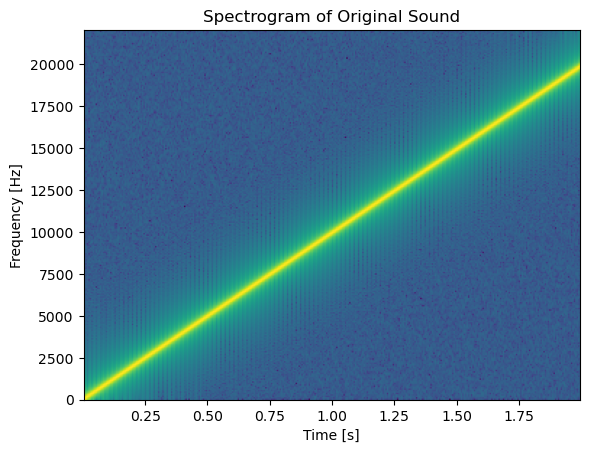

Naive Decimation (No Filter),Your browser does not support the audio element.


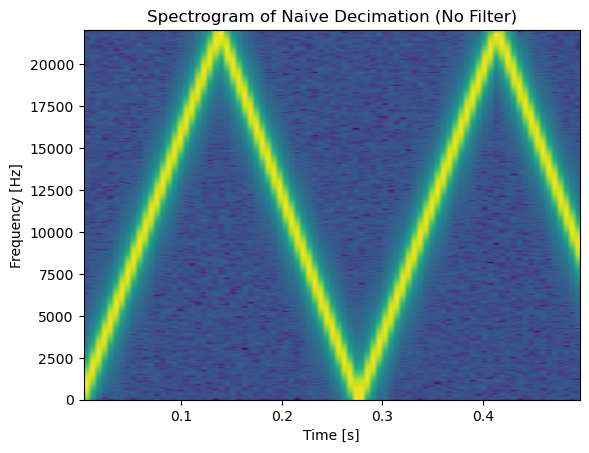

Low-Pass Filtered,Your browser does not support the audio element.


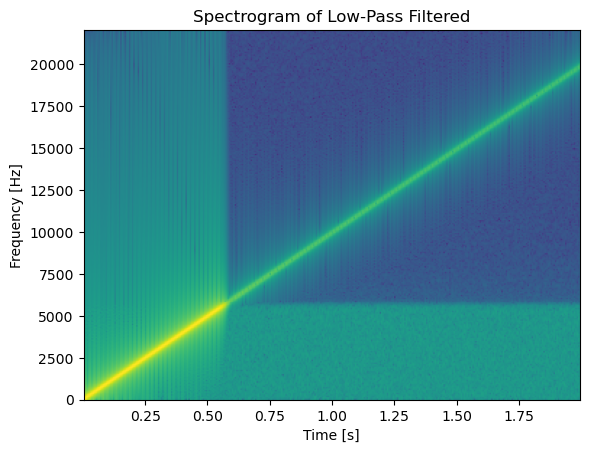

Naive Decimation after anti-aliasing LPF,Your browser does not support the audio element.


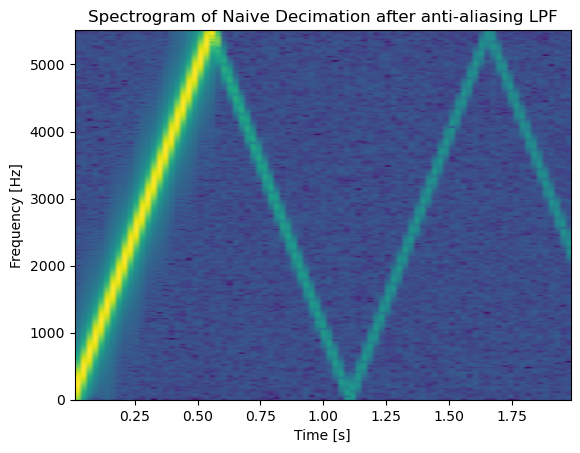

In [4]:
# load chirp.wav
s, sr=sf.read('chirp.wav', dtype='float32')

sound_player( s, sr, 'Original Signal')
plt.specgram( s, NFFT=512, Fs=sr, noverlap=256 )
plt.title('Spectrogram of Original Sound')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()  


target_sr = 11025
factor = sr // target_sr      # 44100 // 11025 = 4 (approx)

# Naive decimation (NO FILTER)
y = s[::factor]

sound_player( y, target_sr, 'Naive Decimation (No Filter)')

plt.specgram( y, NFFT=512, Fs=sr, noverlap=256 )
plt.title('Spectrogram of Naive Decimation (No Filter)')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()  




# Come up with a low-pass filter using firwin and apply it before downsampling
numtaps = 301
cutoff = target_sr / 2  # Nyquist frequency of the target sample rate
fir_coeff = signal.firwin(numtaps, cutoff, fs=sr)
# Apply the filter to the original signal
filtered_s = signal.convolve(s, fir_coeff, mode='same')

sound_player( filtered_s, sr, 'Low-Pass Filtered')

plt.specgram( filtered_s, NFFT=512, Fs=sr, noverlap=256 )
plt.title('Spectrogram of Low-Pass Filtered')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()  





# Naive decmiation again, but on the LPF-ed signal  
y_anti_alias = filtered_s[::factor]
sound_player( y_anti_alias, target_sr, 'Naive Decimation after anti-aliasing LPF')

plt.specgram( y_anti_alias, NFFT=512, Fs=target_sr, noverlap=256 )
plt.title('Spectrogram of Naive Decimation after anti-aliasing LPF')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()  

# sf.write("aliased.wav", y, target_fs)

## Part 1: When to use what 

You want to review S24-34 in Module 2 to solve this problem. 
```morse.wav``` requires us to extract a Morse code which is buried in environmental noise. Design a filter to bring out the beeps.

Do the following:
- Plot the spectrogram of the given sound and identify the problem
- Figure out the left and right cutoff frequencies
- Design a LP filter by using the *right* cutoff frequency
- A HP filter as well, but this time, using the *left* cutoff frequency
- Verify that they do what the are supposed to do
- Combine the two filters to turn them into a band-pass filter that isolates the Morse beeps. 
- Note: Use ```numpy.sinc``` function and manipulate it by introducing the normalized cutoff frequency ```w```, so you get the sinc function you want. 
- Note: Don't use ```scipy.signal```'s filters. I want you to get to the bottom of this. 
- Note: Don't forget to check out the frequency response of your filters using ```scipy.signal.freqz```. Take care of the ripples using windowing. 

I bugged you guys enough. Now, let's cheat and design an IIR Butterworth filter using ```scipy.signal.butter```. Compare its frequency response to your hand-made one. 

Always check out the filtered signals by listening to them and visualizing them via STFT. 

Hint: To apply an IIR filter you can use ```scipy.signal.lfilter```.

History: Back in the day, when ML classifiers were not good enough, signals had to be *preprocessed* a lot by using things like this, so the noise-sensitlve ML models can understand sound better. Nowadays, it's just done by neural networks altogether, but typically at the cost of additional compute and data curation efforts.  


Original Sound,Your browser does not support the audio element.


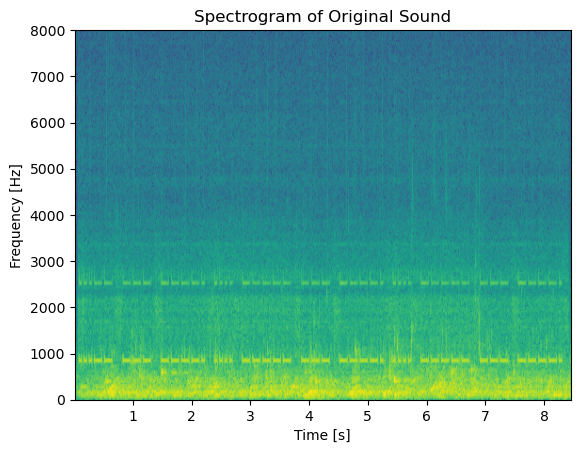

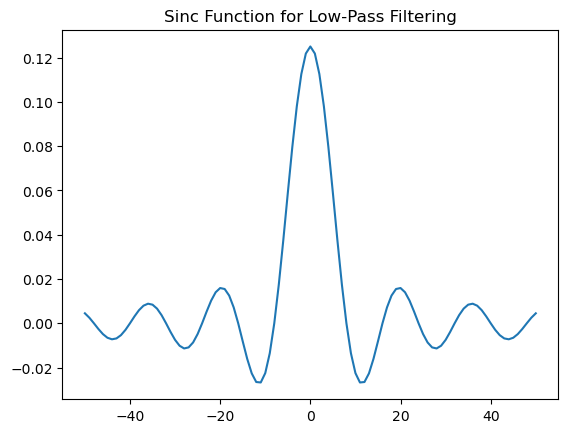

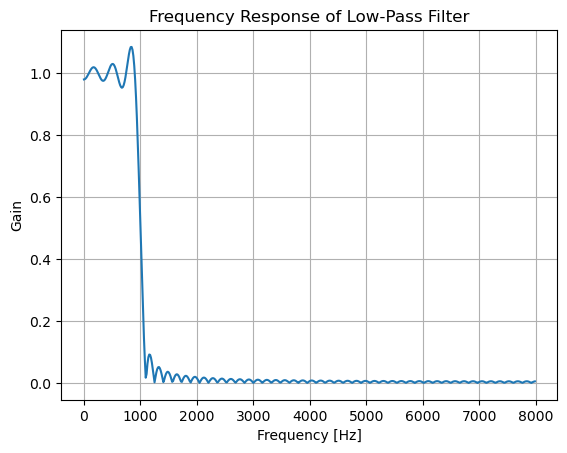

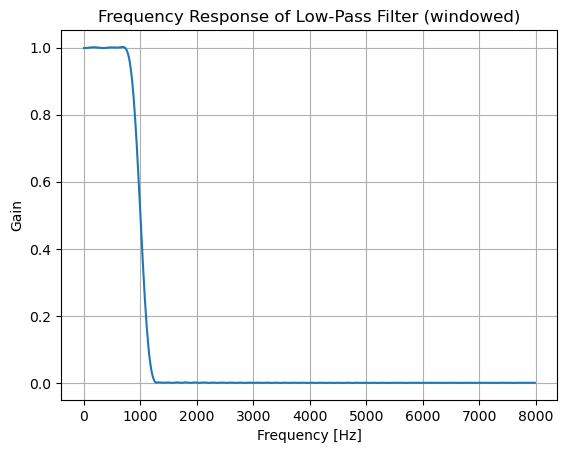

Low-Pass Filtered Sound,Your browser does not support the audio element.


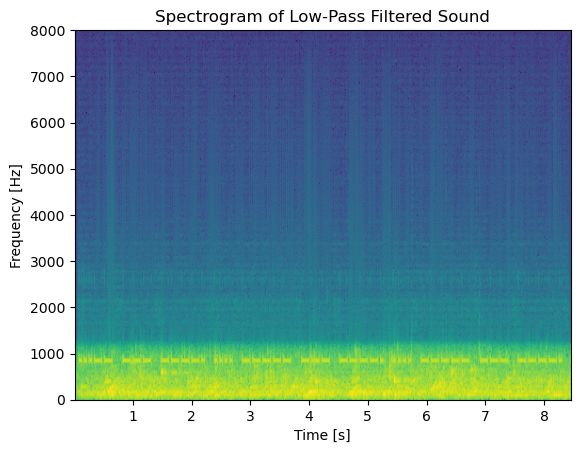

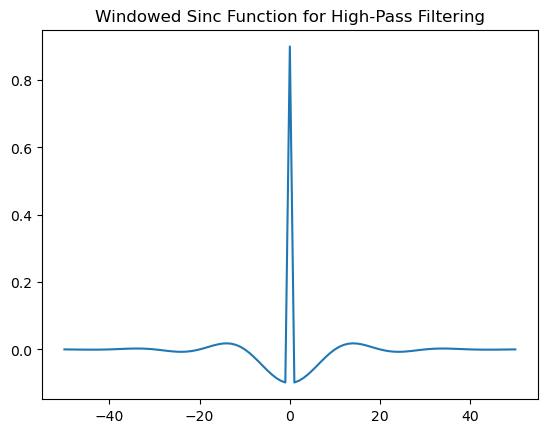

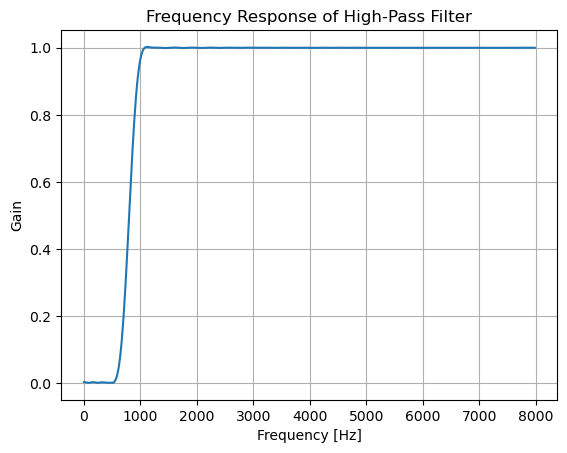

High-Pass Filtered Sound,Your browser does not support the audio element.


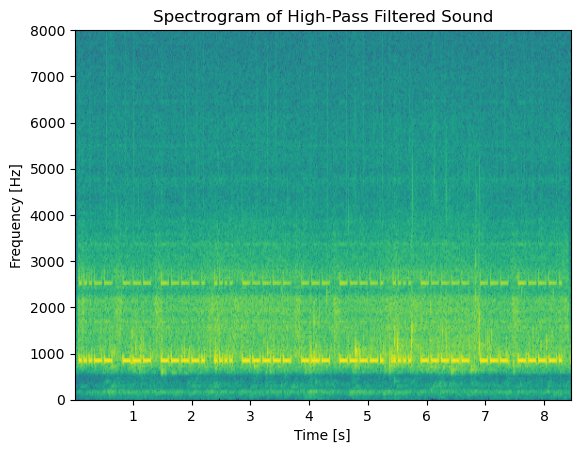

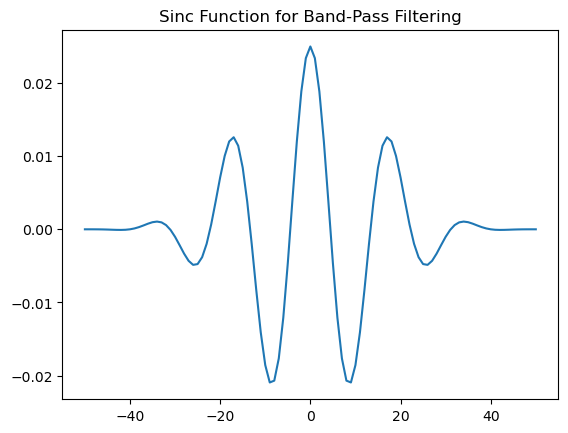

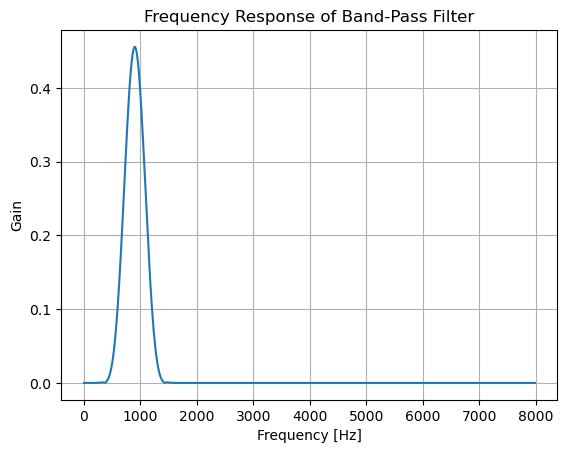

Band-Pass Filtered Sound,Your browser does not support the audio element.


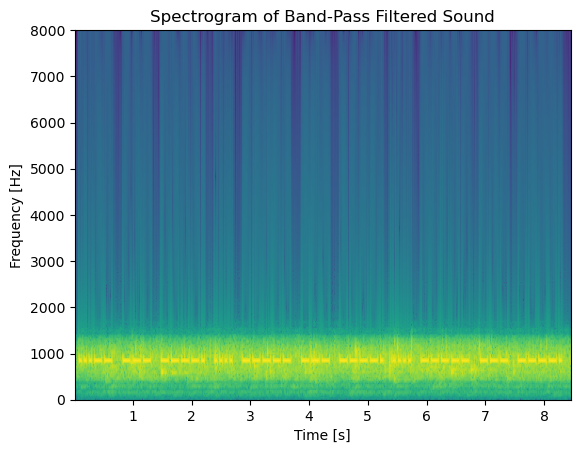

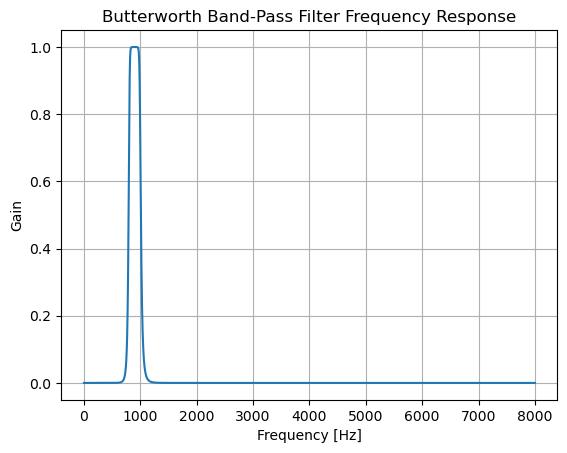

Butterworth Band-Pass Filtered Sound,Your browser does not support the audio element.


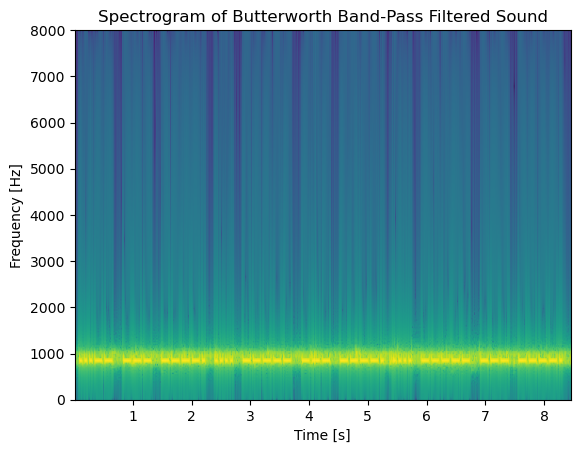

In [8]:
# Load the sound, play it, and plot its spectrogram
s, sample_rate = sf.read('morse.wav')
# YOUR CODE HERE
sound_player( s, rate=sample_rate, label='Original Sound' )
plt.specgram( s, NFFT=512, Fs=sample_rate, noverlap=256 )
plt.title('Spectrogram of Original Sound')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()  

# Define the cutoff frequency and design the LP filter using the sinc function. Check out its shape in the time domain as well as frequency response using freqz.
wh = 1000/(sample_rate//2)
numtaps = 101
x = np.linspace(-(numtaps//2), (numtaps//2), numtaps)
y_lp = wh*np.sinc(wh*x)

plt.figure()
plt.plot(x, y_lp)
plt.title('Sinc Function for Low-Pass Filtering')

Y_lp=signal.freqz(y_lp)
plt.figure()
plt.plot( 0.5*sample_rate*Y_lp[0]/np.pi, np.abs(Y_lp[1]) )
plt.title('Frequency Response of Low-Pass Filter')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain')
plt.grid()
plt.show()

# Window the sinc function, and see the effect in the STFT domain again. 
y_lp *=signal.windows.hamming(numtaps)

Y_lp=signal.freqz(y_lp)
plt.figure()
plt.plot( 0.5*sample_rate*Y_lp[0]/np.pi, np.abs(Y_lp[1]) )
plt.title('Frequency Response of Low-Pass Filter (windowed)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain')
plt.grid()
plt.show()


# Check out the LPF-ed signal in time and frequency domain
filtered_s = signal.convolve(s, y_lp, mode='same')
sound_player( filtered_s, rate=sample_rate, label='Low-Pass Filtered Sound' )
plt.figure()
plt.specgram( filtered_s, NFFT=512, Fs=sample_rate, noverlap=256 )
plt.title('Spectrogram of Low-Pass Filtered Sound')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()


# Ditto for HPF

wl = 800/(sample_rate//2) 
y_hp = -wl*np.sinc(wl*x)
y_hp[numtaps//2] += 1  # Add delta function

y_hp *=signal.windows.hamming(numtaps)
plt.figure()
plt.plot(x, y_hp)
plt.title('Windowed Sinc Function for High-Pass Filtering')  

Y_hp = signal.freqz(y_hp)
plt.figure()
plt.plot( 0.5*sample_rate*Y_hp[0]/np.pi, np.abs(Y_hp[1]) )
plt.title('Frequency Response of High-Pass Filter') 
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain')
plt.grid()
plt.show()      

filtered_s = signal.convolve(s, y_hp, mode='same')
sound_player( filtered_s, rate=sample_rate, label='High-Pass Filtered Sound' )
plt.figure()
plt.specgram( filtered_s, NFFT=512, Fs=sample_rate, noverlap=256 )
plt.title('Spectrogram of High-Pass Filtered Sound')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()  

# Now design a band-pass filter by combining the above two filters
y_bp = wh*np.sinc(wh*x)-wl*np.sinc(wl*x)
y_bp *=signal.windows.hamming(numtaps)
y_bp *= signal.windows.hann(numtaps)
plt.figure()
plt.plot(x, y_bp)
plt.title('Sinc Function for Band-Pass Filtering')  
plt.figure()
Y_bp=signal.freqz(y_bp)
plt.plot( 0.5*sample_rate*Y_bp[0]/np.pi, np.abs(Y_bp[1]) )
plt.title('Frequency Response of Band-Pass Filter')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain')
plt.grid()
plt.show()

filtered_s = signal.convolve(s, y_bp, mode='same')
sound_player( filtered_s, rate=sample_rate, label='Band-Pass Filtered Sound' )
plt.figure()
plt.specgram( filtered_s, NFFT=512, Fs=sample_rate, noverlap=256 )
plt.title('Spectrogram of Band-Pass Filtered Sound')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()  

# Come up with a Butterworth filter that does the same band-pass filtering.
 
b, a = signal.butter(6, [800, 1000], btype='bandpass', fs=sample_rate)
w, h = signal.freqz(b, a, worN=8000)
plt.figure()
plt.plot(0.5*sample_rate*w/np.pi, np.abs(h))
plt.title('Butterworth Band-Pass Filter Frequency Response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain')
plt.grid()
plt.show()

signal.lfilter(b, a, s)
butter_filtered_s = signal.lfilter(b, a, s)
sound_player( butter_filtered_s, rate=sample_rate, label='Butterworth Band-Pass Filtered Sound' )
plt.figure()
plt.specgram( butter_filtered_s, NFFT=512, Fs=sample_rate, noverlap=256 )
plt.title('Spectrogram of Butterworth Band-Pass Filtered Sound')
plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.show()

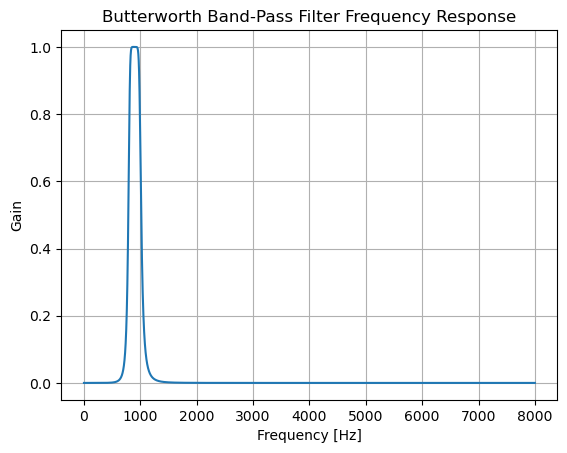

In [7]:
plt.figure()
plt.plot(0.5*sample_rate*w/np.pi, np.abs(h))
plt.title('Butterworth Band-Pass Filter Frequency Response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain')
plt.grid()
plt.show()


## Part 3: Say A

Let's make the computer talk.  To do so we need two things, an *excitation signal* and a filter.  For the excitation we will use something called the "Rosenberg Pulse". A simple version of it will be the same as a cosine, but it will only be zero between phase $0$ and $3\pi/2$.  It will effectively look like a curvy ramp (or a Shark's fin) from zero to one that takes place during the last quarter of each period. Generate a 0.3 sec long Rosenberg pulse with a frequency of 170Hz, at a sampling rate of 8kHz.  It should sound like a short buzzy tone. Create another one with a frequency of 150 Hz, too. See their waveform representations, too. 

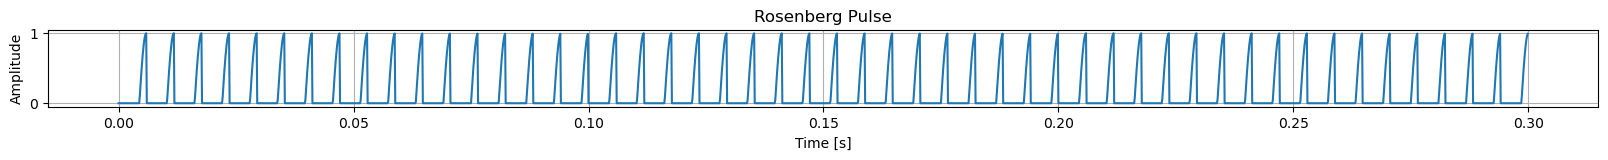

""


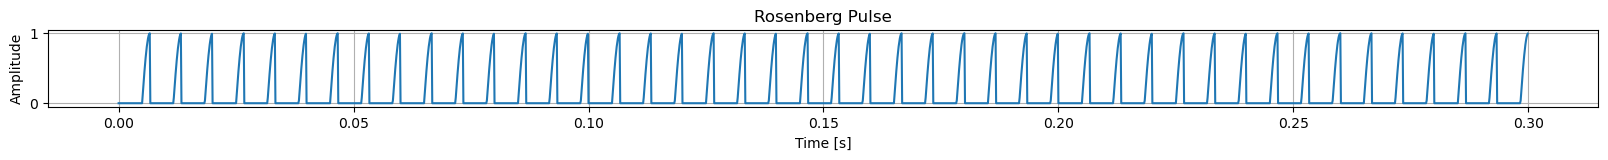

""


In [156]:
# Make the pulse
sr = 8000
t = np.arange(int(0.3*sr)) / sr
freq = 170
phase = 2 * np.pi * freq * t
phase_mod=np.mod(phase, 2*np.pi)
mask = phase_mod < (1.5 * np.pi)

pulse_170=np.cos(phase)
pulse_170[mask==True]=0.0

plt.figure(figsize=(20,1))
plt.plot(t, pulse_170)
plt.title('Rosenberg Pulse')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.show()
sound_player( pulse_200, sr)


freq = 150
phase = 2 * np.pi * freq * t
phase_mod=np.mod(phase, 2*np.pi)
mask = phase_mod < (1.5 * np.pi)

pulse_150=np.cos(phase)
pulse_150[mask==True]=0.0
plt.figure(figsize=(20,1))
plt.plot(t, pulse_150)
plt.title('Rosenberg Pulse')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.show()
sound_player( pulse_150, sr)

Now that you have two glottal pulses as the excitation signal, let's apply some filters to generate two vowels, "eh" and "ee".  In the code snippet below I have two tables that hold the center frequency and amplitude of the five resonances that make each vowel.  To model these resonances, design a bandpass filter with a bandwidth of 90Hz centered at each of the given frequencies.  You will end up with five filters for each vowel.  Then take the pulse sound from above and convolve it with the five filters of each vowel (in parallel, not in series) and add the outputs together and scale them with their corresponding amplitudes in the given tables.  Play the results and verify that they sound like a robotic "a" and an "u".

To design the filters, use the ```scipy.signal.firwin``` function with filters of length 61.

<Figure size 640x480 with 0 Axes>

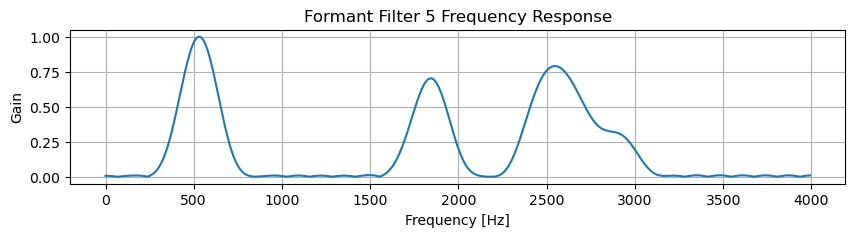

<Figure size 640x480 with 0 Axes>

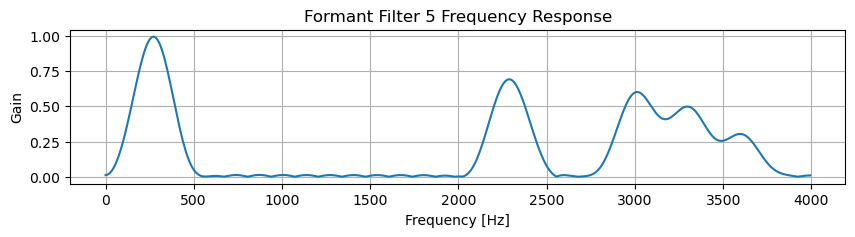

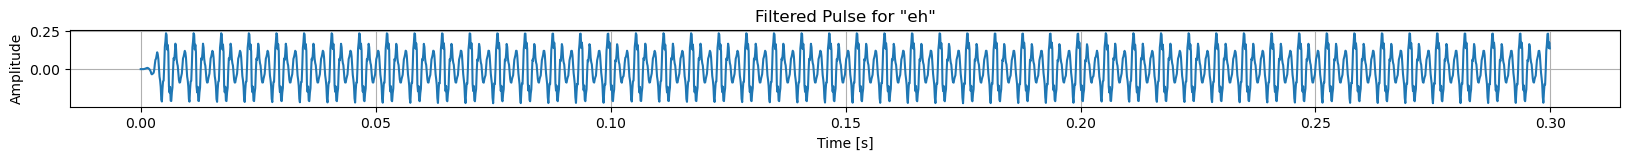

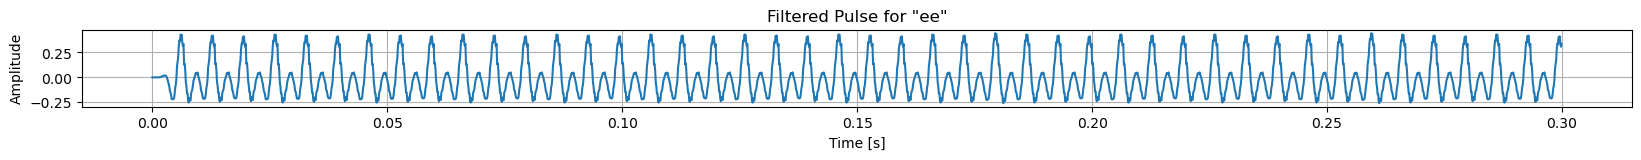

eh


ee


In [167]:
# Formant table for "eh"
Feh = [
    [530, 1840, 2480, 2650, 2900],  # Formant frequencies (Hz)
    [1,    .7,   .6,   .5,   .3],   # Amplitudes
]

# Formant table for "u"
Fee = [
    [270, 2290, 3010, 3300, 3600],  # Formant frequencies (Hz)
    [1,    .7,   .6,   .5,   .3],   # Amplitudes
]

# Apply a sequence of filters to the pulse train and add the results
def vocalize( s, F, sr=8000):
    # s: input sound (the pulse)
    # F: formant table
    
    y = np.zeros_like(s)
    f = np.zeros(61)
    plt.figure()
    for i in range(len(F[0])):
        f+=F[1][i]*signal.firwin(numtaps=61, cutoff=[F[0][i]-45, F[0][i]+45], pass_zero = False, fs=sr)
        
        
    w, h=signal.freqz(f)        
    plt.figure(figsize=(10,2))
    plt.plot( 0.5*sr*w/np.pi, np.abs(h) )
    plt.title(f'Formant Filter {i+1} Frequency Response')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Gain')
    plt.grid()
    plt.show()

    y=signal.convolve( s, f, mode='same' )
    
    return y
	

# Make the two utterances
seh = vocalize( pulse_170, Feh)
see = vocalize( pulse_150, Fee)


plt.figure(figsize=(20,1))
plt.plot(t, seh)
plt.title('Filtered Pulse for "eh"')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

plt.figure(figsize=(20,1))
plt.plot(t, see)
plt.title('Filtered Pulse for "ee"')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.show()



# And play them
sound_player( seh, sr, 'eh')
sound_player( see, sr, 'ee')

Now let's try to compose a word by combining the vowels.  Concatenate the two sounds above and play the result to form the word "A". It will not sound great because the transition from one to the other is too abrupt. To make this a little better, we will need to crossfade the two sounds (just as you have already done for lab 0, part 3).  To do so, use a 200 ms linear crossfade between the two sounds. Play the result and verify that it sounds better. If it sounds more like an "A" who knows if you could get an "A"?

In [168]:
# Concatenate and play the two utterances
conc_s = np.concatenate((seh, see))
sound_player( conc_s, sr, 'Concatenation')


# Crossfade them instead

cross_s = np.zeros_like( conc_s )
fade_out = np.linspace(1, 0, int(0.2 * sr))
fade_in = np.linspace(0, 1, int(0.2 * sr))
seh_end = seh[int(-sr*.2):]*fade_out
see_start = see[:int(sr*.2)]*fade_in
mixed = np.concatenate( (seh[:-int(sr*.2)], seh_end + see_start, see[int(sr*.2):]) )

sound_player( mixed, sr, 'Crossfade')

Concatenation


Crossfade


Now take a minute to respect people who source-filter speech synthesis, who had to do this bit-by-bit for entire sentences! :) 